In [ ]:
#描述性统计
#包括数据数量，维度，缺失率，平均数，中位数等等
#描述性统计类似前期侦查，必不可少

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
#解决中文不能显示问题
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [3]:
#读取数据
data = pd.read_excel('data1.xlsx')

In [4]:
# 查看数据的记录数
n_records = data.shape[0]

In [5]:
n_records

73388

In [6]:
# 了解数据集维度，数据类型
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73388 entries, 0 to 73387
Columns: 108 entries, 省份 to 是否违约
dtypes: float64(29), int64(79)
memory usage: 60.5 MB


In [7]:
# 了解各个特征的统计信息
data.describe()

,省份,市,一级行业名称,二级行业名称,三级行业名称,四级行业名称,成立年限,注册资本原始值万元,实缴资本原始值万元,是否是国企,...,从业人数,产权比率,权益乘数,资产负债率,净利润率,营业收入增长率,总资产增长率,总资产收益率,总资产周转率,是否违约
count,73388.000000,73388.000000,73388.000000,73388.000000,73388.000000,73388.000000,73388.000000,6.936200e+04,3.665000e+04,73388.000000,...,73388.00000,4.465100e+04,4.609400e+04,6.158900e+04,4.703900e+04,4.059300e+04,5.111500e+04,6.300900e+04,6.300700e+04,73388.000000
mean,16.644792,153.720322,10.023096,46.940508,217.999782,483.006377,8.058292,1.141216e+03,1.250467e+03,0.018518,...,7.31388,1.849043e+02,1.116677e+02,1.785685e+02,-9.996440e+01,1.953236e+02,2.004779e+03,-3.012127e+02,9.241069e+01,0.048414
std,8.114103,103.938291,5.027760,27.184488,123.644247,321.921506,6.636175,2.157546e+04,2.134345e+04,0.134816,...,65.59503,3.511802e+04,8.148168e+03,4.296799e+04,2.098689e+04,2.664164e+04,2.751861e+05,6.305486e+04,8.341481e+03,0.214641
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,1.000000e-05,0.000000,...,0.00000,0.000000e+00,0.000000e+00,0.000000e+00,-4.409703e+06,-1.866417e+02,-1.311000e+03,-1.560000e+07,-2.137931e+02,0.000000
25%,9.000000,54.000000,6.000000,22.000000,107.000000,194.000000,3.410000,5.000000e+01,3.000000e+01,0.000000,...,0.00000,0.000000e+00,1.000000e+00,0.000000e+00,-2.888650e-02,-4.078650e-01,-6.084850e-02,-1.506100e-02,0.000000e+00,0.000000
50%,19.000000,133.000000,11.000000,39.000000,210.000000,484.000000,6.170000,1.000000e+02,1.000000e+02,0.000000,...,2.00000,1.455000e-01,1.103514e+00,4.552500e-01,1.636900e-02,0.000000e+00,0.000000e+00,0.000000e+00,3.465080e-01,0.000000
75%,23.000000,251.000000,12.000000,70.000000,333.000000,761.000000,10.480000,5.000000e+02,3.950000e+02,0.000000,...,5.00000,1.646405e+00,2.606118e+00,1.000000e+00,1.542265e-01,5.937500e-01,2.898475e-01,5.263200e-02,1.270408e+00,0.000000
max,30.000000,341.000000,20.000000,95.000000,439.000000,1143.000000,74.000000,3.000000e+06,2.224277e+06,1.000000,...,6500.00000,7.417929e+06,1.120998e+06,1.066327e+07,9.263353e+05,5.335674e+06,4.443116e+07,1.401931e+06,1.152208e+06,1.000000


<Axes: title={'center': '图1.变量缺失率分布'}>

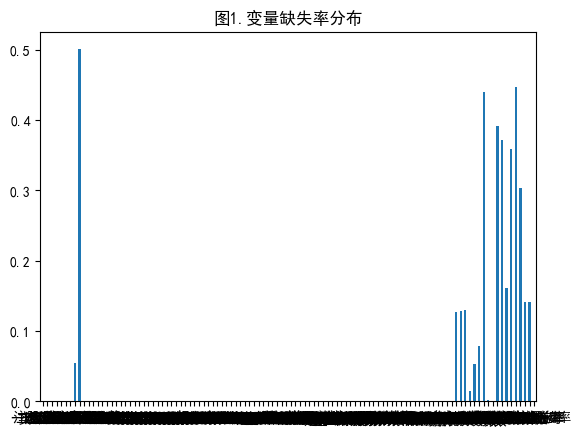

In [8]:
#各个变量缺失率统计
missing_pct=data.apply(lambda x : (len(x)-x.count())/len(x))
missing_pct.plot(kind = "bar", fontsize= 10, rot=0, title= "图1.变量缺失率分布")

In [9]:
missing_pct

省份         0.000000
市          0.000000
一级行业名称     0.000000
二级行业名称     0.000000
三级行业名称     0.000000
             ...   
营业收入增长率    0.446871
总资产增长率     0.303496
总资产收益率     0.141426
总资产周转率     0.141454
是否违约       0.000000
Length: 108, dtype: float64

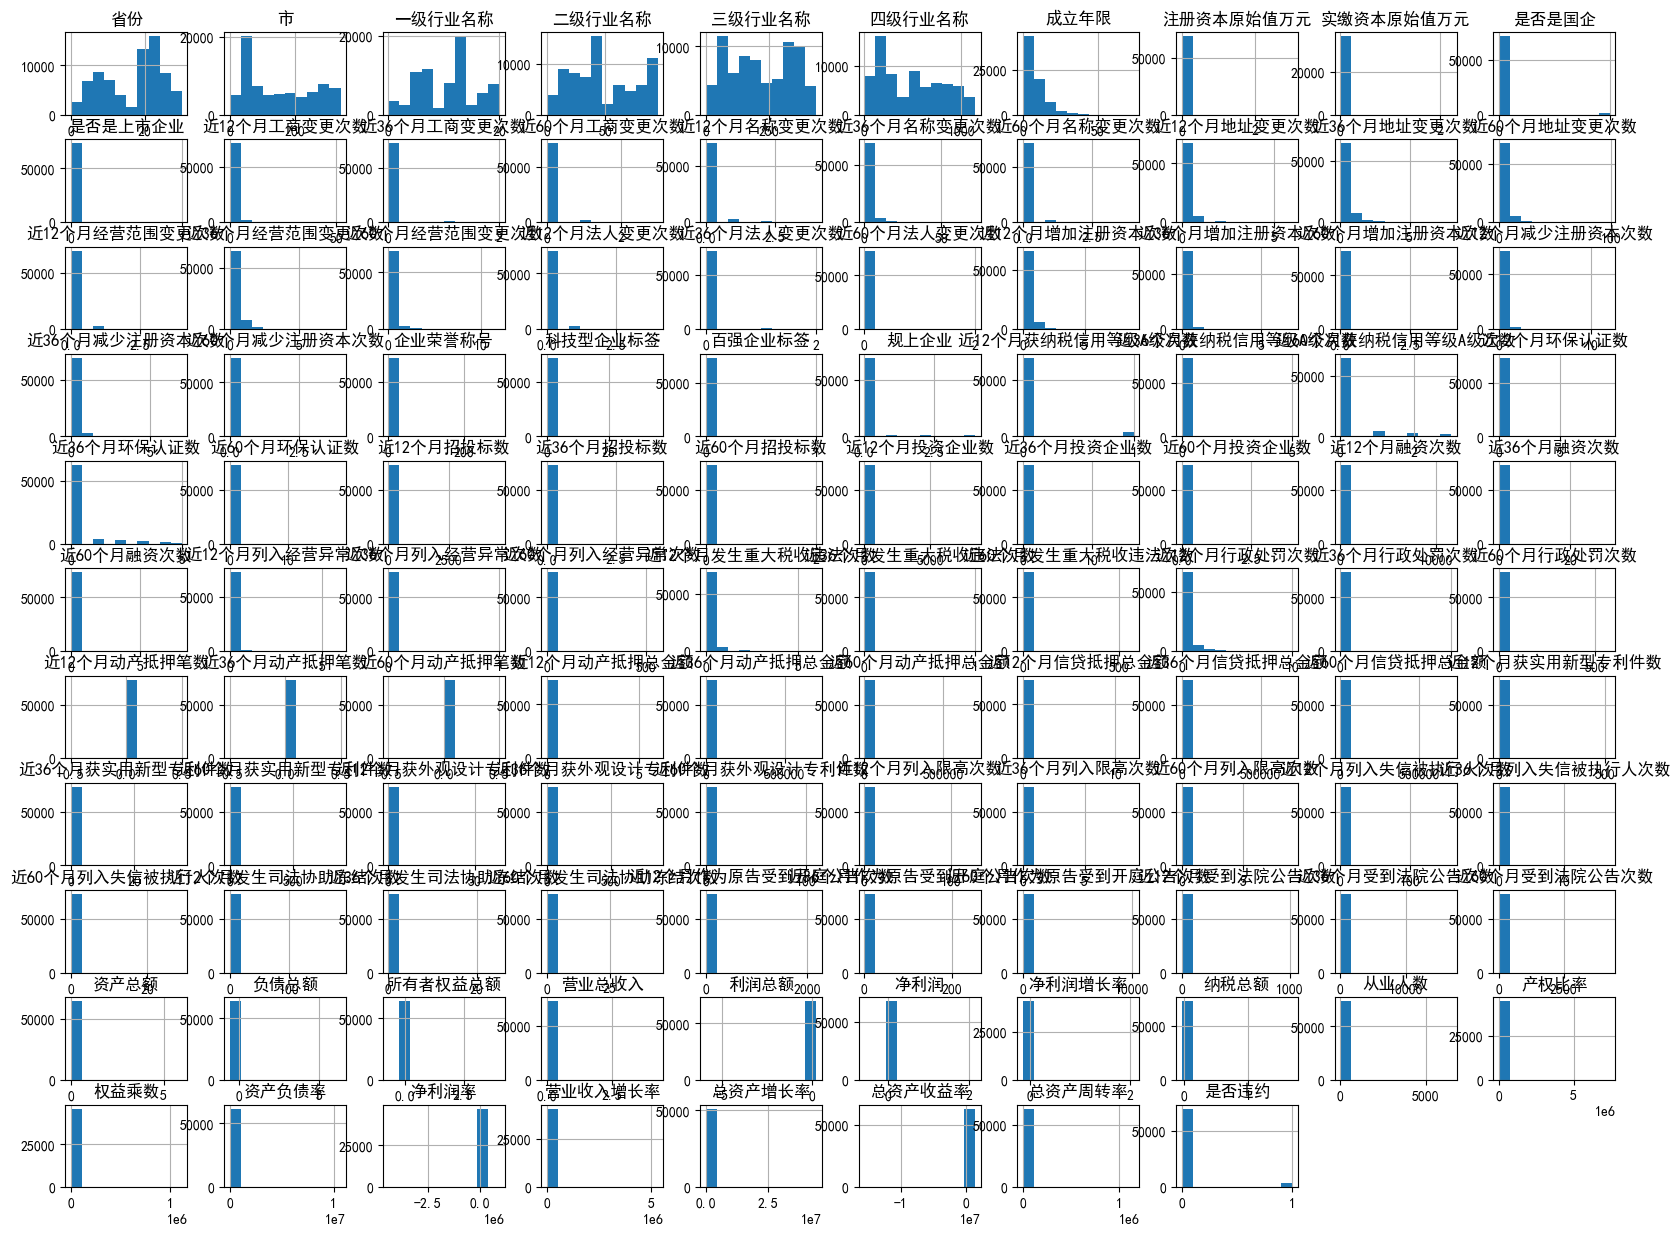

In [10]:
#所有变量频率图
data.hist(figsize=(20,15))
plt.show()

In [ ]:
#.欺诈客户占比
#建模前观察是否存在好欺诈占比严重失衡问题

In [14]:
#查看坏账用户记录数
n_bad = data[data.是否违约 == 1].shape[0]
#查看正常用户记录数
n_good = data[data.是否违约 == 0].shape[0]
#查看坏账用户占比所有用户的情况
percentage_bad = round((n_bad/n_records)*100,2)

In [15]:
percentage_bad

4.84

In [17]:
#好坏客户占比，series数据结构
value_count = data["是否违约"].value_counts()

In [18]:
value_count

是否违约
0    69835
1     3553
Name: count, dtype: int64

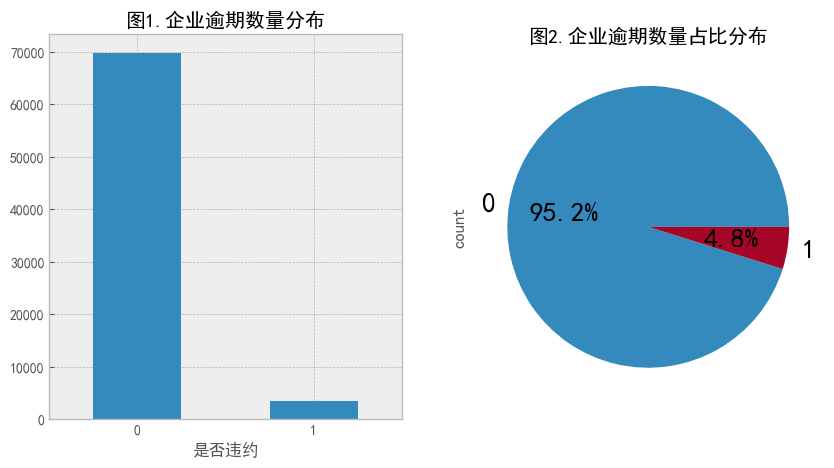

In [23]:
plt.style.use("bmh")
plt.figure(figsize = (10,5))
#画柱状图
ax = plt.subplot(1,2,1)
#rot表示X轴标注的旋转角度，默认是0
value_count.plot(kind = "bar", fontsize= 10, rot=0, title= "图1.企业逾期数量分布")
#画饼状图
ax = plt.subplot(1,2,2)
#autopct小数点后面的数字表示保留小数点几位，fontsize字体大小
value_count.plot(kind = "pie", autopct = "%0.1f%%", title= "图2.企业逾期数量占比分布", fontsize=20)
plt.show()

In [ ]:
#变量相关性概念

In [17]:
#课时4.各个变量的相关性矩阵
matrix_cor=data.corr().round(2)

In [18]:
matrix_cor

,一天去两家医院的天数,就诊的月数,月就诊天数_MAX,月就诊天数_AVG,月就诊医院数_MAX,月就诊医院数_AVG,就诊次数_SUM,月就诊次数_MAX,月就诊次数_AVG,月统筹金额_MAX,...,医疗救助医院申请_SUM,出院诊断病种名称_NN,出院诊断LENTH_MAX,药品在总金额中的占比,个人支付的药品占比,检查总费用在总金额占比,治疗费用在总金额占比,个人支付治疗费用占比,是否挂号,target
一天去两家医院的天数,1.00,0.06,0.47,0.47,0.47,0.54,0.64,0.66,0.64,0.37,...,0.23,0.45,0.09,0.06,-0.01,-0.10,0.00,-0.04,-0.06,0.25
就诊的月数,0.06,1.00,0.16,0.15,0.11,0.10,0.25,0.13,0.13,0.02,...,0.01,0.19,0.08,0.21,-0.04,-0.13,-0.07,-0.01,0.02,-0.08
月就诊天数_MAX,0.47,0.16,1.00,0.95,0.40,0.43,0.92,0.96,0.93,0.48,...,0.21,0.60,0.11,-0.11,0.02,-0.16,0.24,-0.08,-0.13,0.28
月就诊天数_AVG,0.47,0.15,0.95,1.00,0.36,0.42,0.96,0.90,0.98,0.46,...,0.24,0.59,0.14,-0.15,0.01,-0.17,0.28,-0.09,-0.14,0.25
月就诊医院数_MAX,0.47,0.11,0.40,0.36,1.00,0.90,0.43,0.47,0.43,0.18,...,0.03,0.47,0.12,0.14,-0.06,-0.11,-0.07,-0.02,-0.14,0.12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
检查总费用在总金额占比,-0.10,-0.13,-0.16,-0.17,-0.11,-0.13,-0.18,-0.16,-0.17,-0.10,...,-0.03,-0.14,-0.12,-0.29,0.07,1.00,-0.13,0.06,0.08,-0.04
治疗费用在总金额占比,0.00,-0.07,0.24,0.28,-0.07,-0.06,0.23,0.19,0.24,0.44,...,0.10,-0.01,-0.04,-0.85,-0.05,-0.13,1.00,-0.04,-0.05,0.14
个人支付治疗费用占比,-0.04,-0.01,-0.08,-0.09,-0.02,-0.03,-0.08,-0.08,-0.08,-0.02,...,-0.02,-0.07,-0.03,0.02,0.01,0.06,-0.04,1.00,0.07,-0.02
是否挂号,-0.06,0.02,-0.13,-0.14,-0.14,-0.15,-0.13,-0.12,-0.13,-0.04,...,-0.03,-0.17,0.06,0.02,0.06,0.08,-0.05,0.07,1.00,-0.01


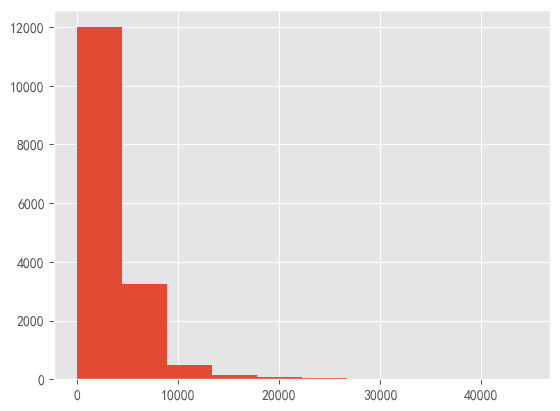

In [36]:
#分期付款金额
#单月统筹金额_MAX在10000范围内占比较多，较高金额的数量较少，这一点可用于检测欺诈骗保用户策略用。
data['月统筹金额_MAX'].hist()
plt.show()

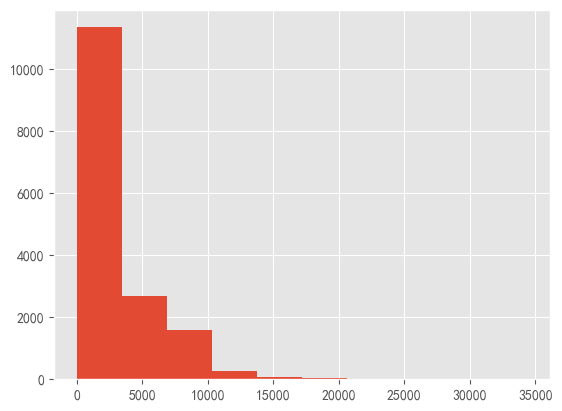

In [21]:
#中草药费发生金额_SUM
#中草药费发生金额_SUM在1万范围内占比较多，较高金额的数量较少，这一点可用于检测欺诈骗保用户策略用。
data['中草药费发生金额_SUM'].hist()
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14696\1451310482.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data.月药品金额_MAX,fit=norm,kde=True,color='blue')


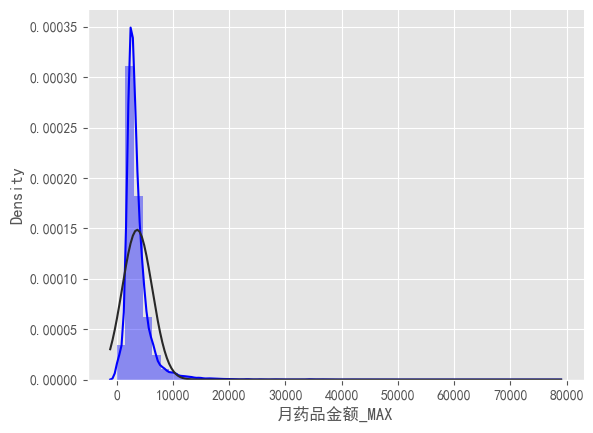

In [22]:
#增加正太分布图，月药品金额_MAX主要分布在0-10000元内，这一点可用于检测欺诈骗保用户策略用。
from scipy.stats import norm   
sns.distplot(data.月药品金额_MAX,fit=norm,kde=True,color='blue')
sns.despine(top=True)    

<Axes: ylabel='count'>

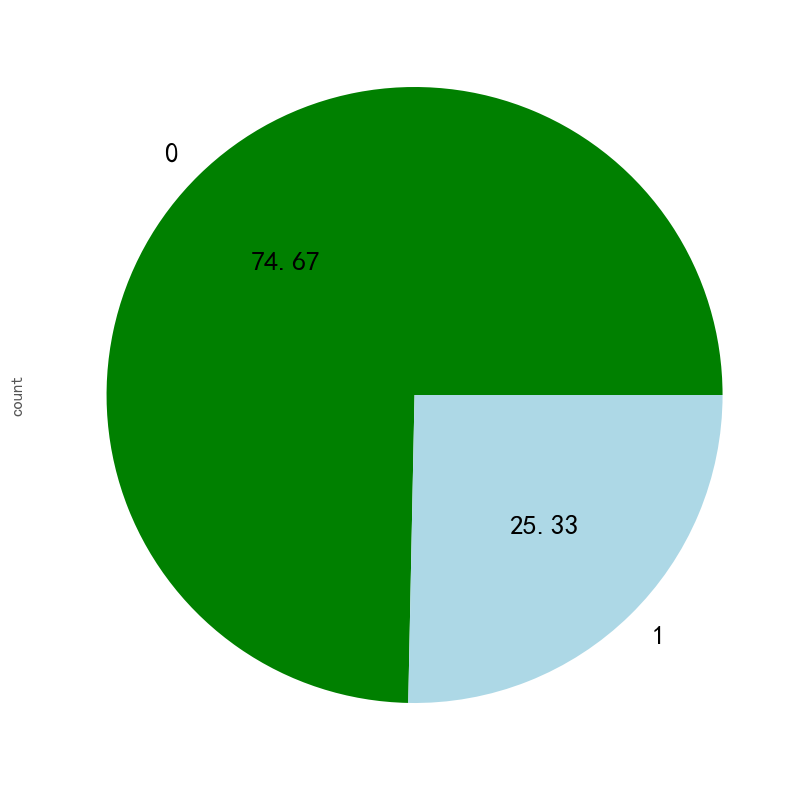

In [27]:
term_counts=data.是否挂号.value_counts()
term_counts.plot.pie(autopct='%.2f',figsize=(10, 10),fontsize=20,
                     colors = ['green','lightblue']) #74%患者就诊选择挂号

<Axes: ylabel='count'>

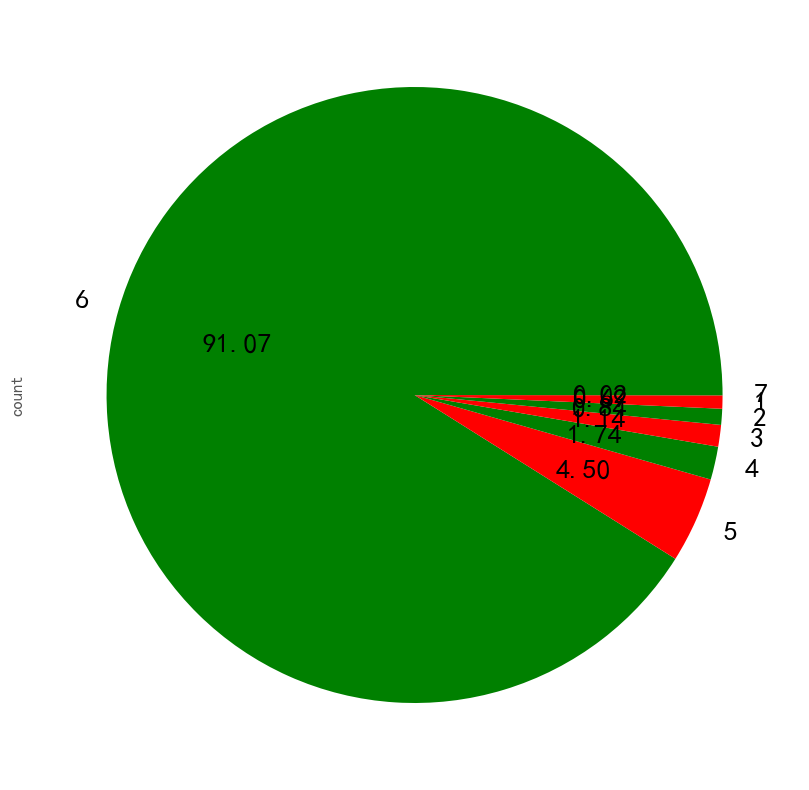

In [29]:
data.就诊的月数.value_counts().plot.pie(autopct='%.2f',figsize=(10, 10),colors = ['green','red'],fontsize=20) #超过90%患者就诊月数为6个月

<Axes: title={'center': '图1.月就诊天数_MAX分布图'}, xlabel='月就诊天数_MAX'>

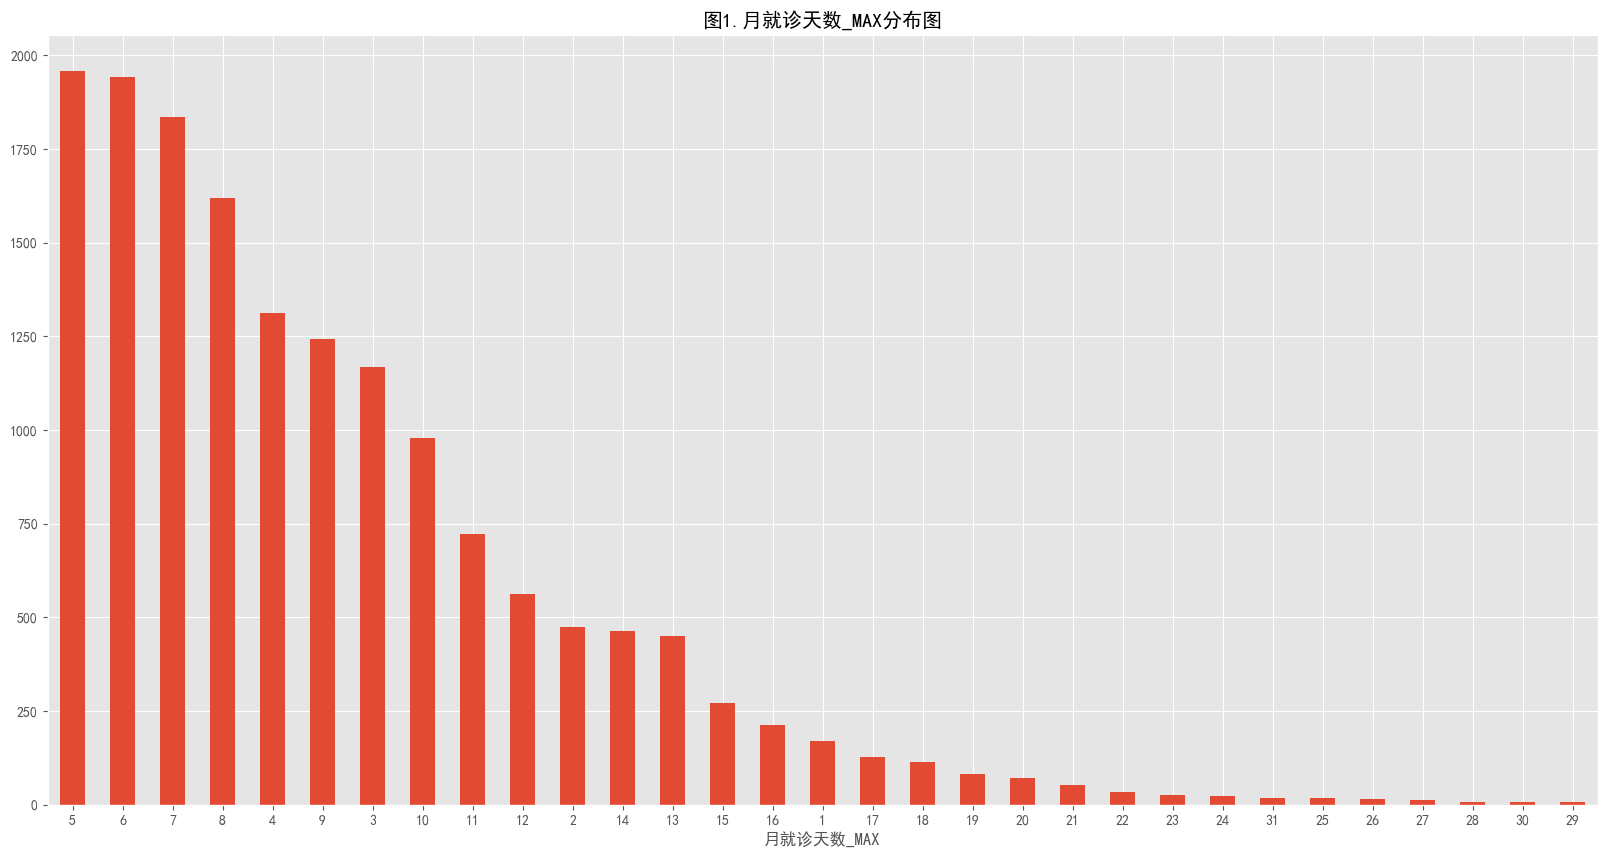

In [34]:
#月就诊天数_MAX5-8天的患者最多
data.月就诊天数_MAX.value_counts().plot(kind = "bar", fontsize= 10, rot=0, title= "图1.月就诊天数_MAX分布图",figsize=(20, 10))     